In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [26]:
# Reading the CSV into a DataFrame
df = pd.read_csv('/Users/alanphan/Documents/WGU MSDA/Course Materials/D600/Task 2/data/D600 Task 2 Dataset 1 Housing Information.csv')
df

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6987,307821.1758,550.00,2.111022,4,892.35,11.89,7.97,28.18,19.23,...,4.76,3.81,6.87,No,White,Yes,1,18,241131.63070,1
6996,6995,421368.8869,1726.12,4.056115,2,943.19,34.06,5.82,90.45,17.60,...,5.31,9.84,10.00,No,White,Yes,1,18,481604.80730,1
6997,6996,473382.5348,1026.36,2.077177,5,149.31,0.10,8.81,31.79,11.59,...,4.98,7.47,2.96,No,Green,No,1,13,380555.49390,1
6998,6998,343397.9756,2218.22,1.000000,4,526.81,11.18,9.20,15.21,3.96,...,4.68,7.66,6.12,No,Blue,Yes,1,10,442610.31710,0


In [27]:
# Making sure there are no duplicate rows
duplicates = df.duplicated().sum()
print(f'There are {duplicates} duplicate rows.')

There are 0 duplicate rows.


In [28]:
# Dependent and independent variables
variables = ['IsLuxury', 'NumBedrooms', 'SquareFootage']
df = df[variables]
df

,IsLuxury,NumBedrooms,SquareFootage
0,0,4,566.62
1,0,2,1472.34
2,0,3,550.00
3,0,2,941.81
4,0,3,550.00
...,...,...,...
6995,1,4,550.00
6996,1,2,1726.12
6997,1,5,1026.36
6998,0,4,2218.22


In [29]:
# Descriptive statistics of the variables
df.describe()

,IsLuxury,NumBedrooms,SquareFootage
count,7000.00000,7000.000000,7000.000000
mean,0.50400,3.008571,1048.947459
std,0.50002,1.021940,426.010482
min,0.00000,1.000000,550.000000
25%,0.00000,2.000000,660.815000
50%,1.00000,3.000000,996.320000
75%,1.00000,4.000000,1342.292500
max,1.00000,7.000000,2874.700000


In [30]:
# Distribution of IsLuxury
unique_values = df['IsLuxury'].unique()
frequency = df['IsLuxury'].value_counts()
proportions = df['IsLuxury'].value_counts(normalize = True)

print(f'Unique Values: {unique_values}')
print(f'\nFrequency: {frequency}')
print(f'\nProportions: {proportions}')

Unique Values: [0 1]

Frequency: IsLuxury
1    3528
0    3472
Name: count, dtype: int64

Proportions: IsLuxury
1    0.504
0    0.496
Name: proportion, dtype: float64


In [31]:
# Finding mode for IsLuxury
IsLuxury_mode = df['IsLuxury'].mode()[0]
print(f"Mode of IsLuxury: {IsLuxury_mode}")

# Finding mode for NumBedrooms
NumBedrooms_mode = df['NumBedrooms'].mode()[0]
print(f"Mode of NumBedrooms: {NumBedrooms_mode}")

# Finding mode for SquareFootage
SquareFootage_mode = df['SquareFootage'].mode()[0]
print(f"Mode of SquareFootage: {SquareFootage_mode}")

Mode of IsLuxury: 1
Mode of NumBedrooms: 3
Mode of SquareFootage: 550.0


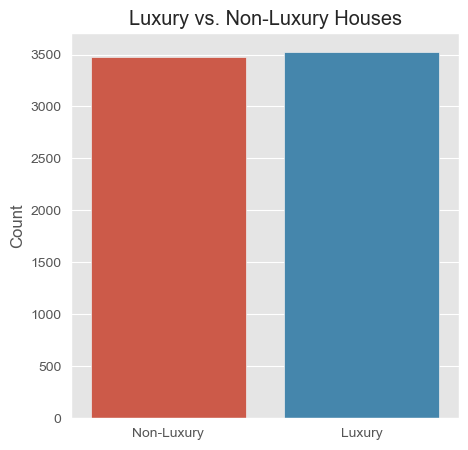

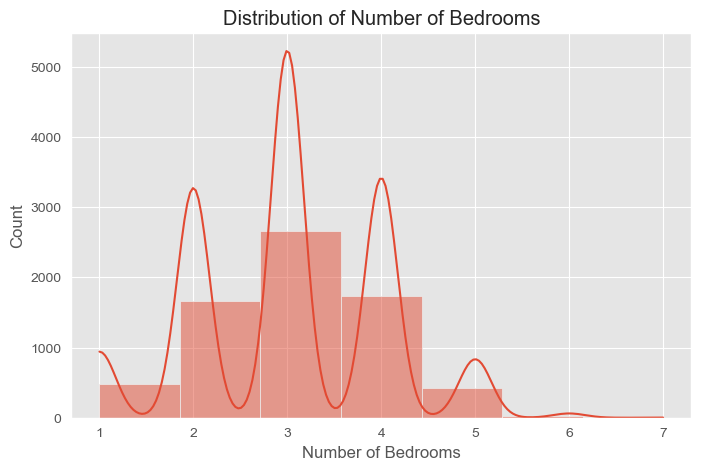

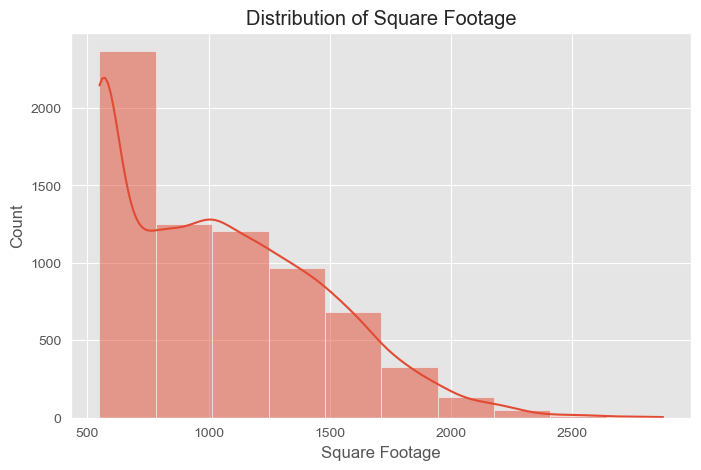

In [32]:
# Univariate visualizations
# Count plot of the dependent variable IsLuxury
plt.figure(figsize = (5, 5))
sns.countplot(df, x = 'IsLuxury', hue = 'IsLuxury', legend = False)
plt.title('Luxury vs. Non-Luxury Houses')
plt.xticks([0, 1], ['Non-Luxury', 'Luxury'])
plt.ylabel('Count')
plt.xlabel('')

# Histogram of the independent variable NumBedrooms
plt.figure(figsize = (8, 5))
unique_bedrooms = df['NumBedrooms'].nunique()
sns.histplot(df['NumBedrooms'], bins = unique_bedrooms, kde = True)
plt.title('Distribution of Number of Bedrooms')
plt.ylabel('Count')
plt.xlabel('Number of Bedrooms')

# Histogram of the independent variable SquareFootage
plt.figure(figsize = (8, 5))
sns.histplot(df['SquareFootage'], bins = 10, kde = True)
plt.title('Distribution of Square Footage')
plt.ylabel('Count')
plt.xlabel('Square Footage');

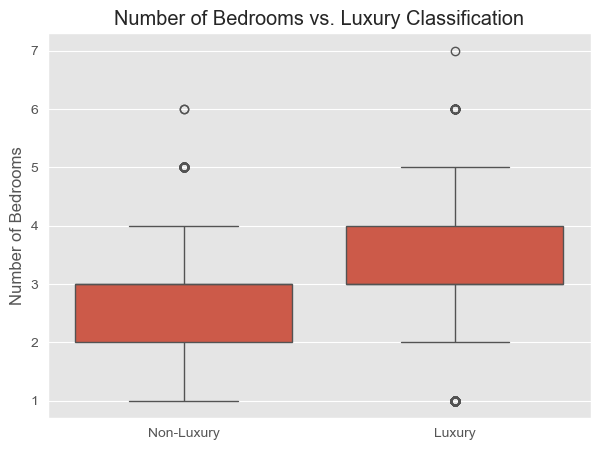

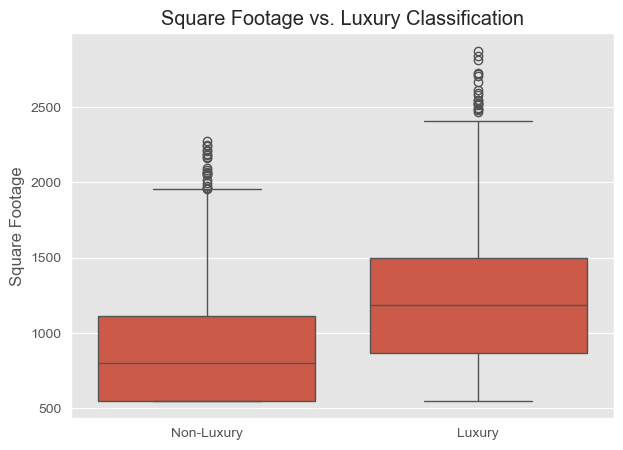

In [33]:
# Bivariate visualizations
# Box plot of NumBedrooms vs. IsLuxury
plt.figure(figsize = (7, 5))
sns.boxplot(data = df, x = 'IsLuxury', y = 'NumBedrooms')
plt.title('Number of Bedrooms vs. Luxury Classification')
plt.xticks([0, 1], ['Non-Luxury', 'Luxury'])
plt.ylabel('Number of Bedrooms')
plt.xlabel('')

# Box plot of SquareFootage vs. IsLuxury
plt.figure(figsize = (7, 5))
sns.boxplot(data = df, x = 'IsLuxury', y = 'SquareFootage')
plt.title('Square Footage vs. Luxury Classification')
plt.xticks([0, 1], ['Non-Luxury', 'Luxury'])
plt.ylabel('Square Footage')
plt.xlabel('');

In [34]:
# Splitting the data 80/20 into training and test datasets to avoid any data leakage
train_df, test_df = train_test_split(df, test_size = 0.2, random_state = 42)

# Shapes of the two datasets
print(f"Training dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")

Training dataset shape: (5600, 3)
Test dataset shape: (1400, 3)


In [35]:
# Saving the two datasets as CSV files
train_df.to_csv('Training Dataset.csv', index = False)
test_df.to_csv('Test Dataset.csv', index = False)

In [36]:
# Creating X_train, y_train, X_test, and y_test
X_train = train_df.drop('IsLuxury', axis = 1)
y_train = train_df['IsLuxury']
X_test = test_df.drop('IsLuxury', axis = 1)
y_test = test_df['IsLuxury']

# Shapes of X_train, y_train, X_test, and y_test
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5600, 2)
y_train shape: (5600,)
X_test shape: (1400, 2)
y_test shape: (1400,)


In [37]:
# Adding the constant
X_train = sm.add_constant(X_train)

# Calculating VIF values
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

vif_data.index = vif_data.index + 1 # Make the index start at 1 instead of 0
vif_data

,Feature,VIF
1,const,14.409831
2,NumBedrooms,1.008953
3,SquareFootage,1.008953


In [38]:
# Initial logistic regression
model = sm.Logit(y_train, X_train).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.574255
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               IsLuxury   No. Observations:                 5600
Model:                          Logit   Df Residuals:                     5597
Method:                           MLE   Df Model:                            2
Date:                Sat, 29 Mar 2025   Pseudo R-squ.:                  0.1714
Time:                        22:10:54   Log-Likelihood:                -3215.8
converged:                       True   LL-Null:                       -3881.2
Covariance Type:            nonrobust   LLR p-value:                1.092e-289
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.1645      0.138    -30.140      0.000      -4.435      -3.894
NumBedrooms       0.7200      0.032     22.227      0.000       0.656       0.783
SquareFootage     0.0020   7.95e-05     24.536      0.000       0.002       0.002
=================================================================================
"""

In [39]:
# Backward stepwise elimination
# Function will take in X and y
def backward_elimination(X, y, significance_level = 0.05):
    while True:
        model = sm.Logit(y, X).fit() # Fit the logistic regression model
        p_values = model.pvalues.drop('const') # Get the p-values of the independent variables, ignore const
        max_p_value = p_values.max() # Find the max p-value
        if max_p_value > significance_level: # If the max p-value is > 0.05
            feature_to_drop = p_values.idxmax() # idxmax() returns the index of the highest p-value, which is the column name to drop from X
            print(f"Dropping {feature_to_drop} (p-value: {max_p_value:.4f})")
            X = X.drop(feature_to_drop, axis = 1) # Drop the feature
        else:
            break
    return model, X.columns.to_list()

optimized_model, selected_features = backward_elimination(X_train, y_train)
optimized_model.summary()

Optimization terminated successfully.
         Current function value: 0.574255
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               IsLuxury   No. Observations:                 5600
Model:                          Logit   Df Residuals:                     5597
Method:                           MLE   Df Model:                            2
Date:                Sat, 29 Mar 2025   Pseudo R-squ.:                  0.1714
Time:                        22:12:33   Log-Likelihood:                -3215.8
converged:                       True   LL-Null:                       -3881.2
Covariance Type:            nonrobust   LLR p-value:                1.092e-289
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.1645      0.138    -30.140      0.000      -4.435      -3.894
NumBedrooms       0.7200      0.032     22.227      0.000       0.656       0.783
SquareFootage     0.0020   7.95e-05     24.536      0.000       0.002       0.002
=================================================================================
"""

1. ```optimized_model.predict(X_train)``` produces probabilities (ex. 0.2, 0.7, 0.4, 0.9)
2. Compare each probability to the threshold of 0.5
    - If a probability is > 0.5, then it's classified as luxury and the boolean value ```True``` is returned.
    - If a probability is < 0.5, then it's classified as non-luxury and the boolean value ```False``` is returned.
3. ```astype(int)``` converts the boolean values to binary integers (1 for True, 0 for False).

In [40]:
# Making predictions on the training set
y_train_pred = (optimized_model.predict(X_train) > 0.5).astype(int)

# Creating the confusion matrix
conf_matrix = confusion_matrix(y_train, y_train_pred)

# Calculating accuracy
accuracy = accuracy_score(y_train, y_train_pred)

# Displaying results
print("Confusion Matrix:")
print(conf_matrix)
print(f"\nAccuracy: {accuracy:.4f}")

Confusion Matrix:
[[2010  755]
 [ 837 1998]]

Accuracy: 0.7157


In [41]:
# Add constant to X_test
X_test = sm.add_constant(X_test)

# Making predictions on the test set
y_test_pred = (optimized_model.predict(X_test) > 0.5).astype(int)

# Creating the confusion matrix
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

# Calculating accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Displaying results
print("Test Confusion Matrix:")
print(test_conf_matrix)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

Test Confusion Matrix:
[[522 185]
 [208 485]]

Test Accuracy: 0.7193


In [42]:
# Actual Luxury Classification vs. Predicted Luxury Classification
actual_vs_predicted = pd.DataFrame({'Actual Luxury Classification': y_test,
                                    'Predicted Probability': optimized_model.predict(X_test),
                                    'Predicted Luxury Classification': y_test_pred})
actual_vs_predicted

,Actual Luxury Classification,Predicted Probability,Predicted Luxury Classification
6500,1,0.725551,1
2944,0,0.342758,0
2024,0,0.282768,0
263,0,0.160834,0
4350,1,0.869377,1
...,...,...,...
3484,0,0.268797,0
1860,0,0.378051,0
4974,1,0.425289,0
387,0,0.408132,0


In [43]:
# Making some predictions
# Sample data points
sample_data = pd.DataFrame({'NumBedrooms': [3, 4, 5, 2],
                            'SquareFootage': [1500, 2500, 4000, 800]})

# Adding constant term for statsmodels
sample_data = sm.add_constant(sample_data)

# Making the predictions
predicted_probs = optimized_model.predict(sample_data)

# Converting to binary integers
predicted_class = (predicted_probs > 0.5).astype(int)

# Combining results
predictions = pd.DataFrame({
    'NumBedrooms': sample_data['NumBedrooms'],
    'SquareFootage': sample_data['SquareFootage'],
    'Probability': predicted_probs,
    'Luxury Classification': predicted_class})

predictions

,NumBedrooms,SquareFootage,Probability,Luxury Classification
0,3,1500,0.715163,1
1,4,2500,0.973162,1
2,5,4000,0.999280,1
3,2,800,0.237852,0
